## Libraries needed

In [ ]:
# Instalar NumPy
!python -m pip install numpy

# Instalar scikit-learn (para KD-tree)
!python -m pip install scikit-learn

# Instalar pymotion (para generar CSV desde BVH)
!python -m pip install upc-pymotion

!python -m pip install upc-pymotion matplotlib

pip install upc-pymotion[viewer] 

In [15]:
import os
import numpy as np
from math import cos, radians
from sklearn.neighbors import KDTree
from pymotion.io.bvh import BVH
import matplotlib.pyplot as plt

# =========================
# Parameters
# =========================

STEP = 10                          # Process every N frames
ANGLE_THRESHOLD_DEG = 30           # Direction change threshold
ANGLE_THRESHOLD_COS = cos(radians(ANGLE_THRESHOLD_DEG))
MIN_DISPLACEMENT = 1e-3            # Ignore tiny movements
GROUND_AXES = (0, 2)               # x, z

# =========================
# Utilities (Funciones)
# =========================

def cosine_between(v1, v2):
    """
    Compute the cosine of the angle between two vectors.
    Useful to detect sudden changes in motion direction.
    """
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))


def load_root_positions_from_bvh(bvh_path):
    """
    Load the global root joint positions from a BVH file.

    Parameters:
        bvh_path (str): Path to the BVH file.

    Returns:
        np.ndarray: Array of shape (num_frames, 3) containing
                    global root positions (x, y, z) per frame.
    """
    bvh = BVH()
    bvh.load(bvh_path)
    _, local_positions, _, _, _, _ = bvh.get_data()
    global_positions = local_positions[:, 0, :]  # root joint
    return global_positions

# =========================
# KD-tree Data Construction
# =========================

def build_motion_dataset_from_bvhs(bvh_files):
    """
    Build a KD-tree dataset from multiple BVH files combined.

    Parameters:
        bvh_files (list of str): List of BVH file paths.

    Returns:
        X (np.ndarray): KD-tree points of shape (N, 3) [dx, dz, time].
        metadata (list of tuples): (file_id, start_frame) for each point.

    Notes:
        - Handles BVH files with any number of frames safely.
        - Projects motion onto the ground plane (x, z).
        - Splits motion segments if displacement is too small or direction changes sharply.
    """
    entries = []

    for file_id, bvh_file in enumerate(bvh_files):
        global_positions = load_root_positions_from_bvh(bvh_file)
        # Ensure it's a proper numpy array of shape (num_frames, 3)
        global_positions = np.array(global_positions, dtype=float)
        num_frames = len(global_positions)

        if num_frames < 2:
            # Skip BVHs with too few frames
            continue

        root_pos = global_positions[0]
        prev_disp = None
        offset = np.array([0.0, 0.0])
        current_start_frame = 0

        for f in range(STEP, num_frames, STEP):
            new_root_pos = global_positions[f]

            # Compute displacement in X-Z plane
            disp = np.array([
                new_root_pos[0] - root_pos[0],
                new_root_pos[2] - root_pos[2]
            ])
            root_pos = new_root_pos
            disp_len = np.linalg.norm(disp)

            # Reset segment if displacement is too small
            if disp_len < MIN_DISPLACEMENT:
                current_start_frame = f
                offset[:] = 0.0
                prev_disp = None
                continue

            # Reset segment if direction changes sharply
            if prev_disp is not None:
                cos_angle = cosine_between(disp, prev_disp)
                if cos_angle < ANGLE_THRESHOLD_COS:
                    current_start_frame = f
                    offset[:] = 0.0
                    prev_disp = None
                    continue

            # Accumulate displacement and elapsed time
            offset += disp
            time = f - current_start_frame

            # Save KD-tree point and metadata
            entries.append([
                offset[0],          # displacement_x
                offset[1],          # displacement_z
                time,               # elapsed time
                file_id,            # which BVH file
                current_start_frame # starting frame of segment
            ])
            prev_disp = disp

    # Split into KD-tree points and metadata
    X = np.array([[e[0], e[1], e[2]] for e in entries])
    metadata = [(e[3], e[4]) for e in entries]

    return X, metadata

# =========================
# KD-tree Wrapper
# =========================

class MotionKDTree:
    """
    Wrapper for a KD-tree that stores motion segments and allows
    querying for the best matching motion sequence.
    """

    def __init__(self, X, metadata):
        """
        Initialize KD-tree with motion data.
        """
        self.tree = KDTree(X)
        self.metadata = metadata

    def query(self, displacement_x, displacement_z, time, k=5):
        """
        Query the KD-tree for the k closest motion segments.

        Returns:
            list of dicts: Each dict contains:
                - file_id: index of BVH file
                - start_frame: starting frame of the motion segment
                - distance: KD-tree distance to the query point
        """
        query_point = np.array([[displacement_x, displacement_z, time]])
        dist, idx = self.tree.query(query_point, k=k)
        results = []
        for i, d in zip(idx[0], dist[0]):
            file_id, start_frame = self.metadata[i]
            results.append({"file_id": file_id, "start_frame": start_frame, "distance": d})
        return results

Found 20 BVH files
KD-tree built with 14960 points
Query results:
BVH: Padel6Junio2025-006.bvh, start_frame: 3950, distance: 0.0578
BVH: Padel6Junio2025-010.bvh, start_frame: 3780, distance: 0.0736
BVH: Padel6Junio2025-005.bvh, start_frame: 4590, distance: 0.1000


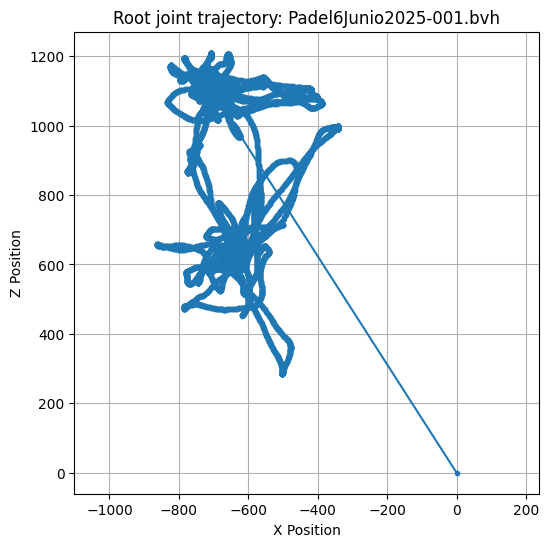

In [16]:
# =========================
# Example Usage
# =========================

if __name__ == "__main__":

    # -------------------------
    # 1. Load BVH files
    # -------------------------
    bvh_folder = r"C:\Users\jiabo\Desktop\TFM\BBDD-professional\BVH processed"
    bvh_files = [os.path.join(bvh_folder, f) for f in os.listdir(bvh_folder) if f.endswith(".bvh")]

    print(f"Found {len(bvh_files)} BVH files")

    # -------------------------
    # 2. Build KD-tree dataset
    # -------------------------
    X, metadata = build_motion_dataset_from_bvhs(bvh_files)
    motion_tree = MotionKDTree(X, metadata)
    print(f"KD-tree built with {len(X)} points")

    # -------------------------
    # 3. Example query
    # -------------------------
    dx, dz, t = 1.0, 0.5, 20
    results = motion_tree.query(dx, dz, t, k=3)
    print("Query results:")
    for r in results:
        file_name = os.path.basename(bvh_files[r['file_id']])
        print(f"BVH: {file_name}, start_frame: {r['start_frame']}, distance: {r['distance']:.4f}")

    # -------------------------
    # 4. Plot trajectory of the first BVH
    # -------------------------
    global_positions = load_root_positions_from_bvh(bvh_files[0])
    x = global_positions[:, 0]
    z = global_positions[:, 2]

    plt.figure(figsize=(6, 6))
    plt.plot(x, z, '-o', markersize=3)
    plt.xlabel("X Position")
    plt.ylabel("Z Position")
    plt.title(f"Root joint trajectory: {os.path.basename(bvh_files[0])}")
    plt.grid(True)
    plt.axis("equal")
    plt.show()

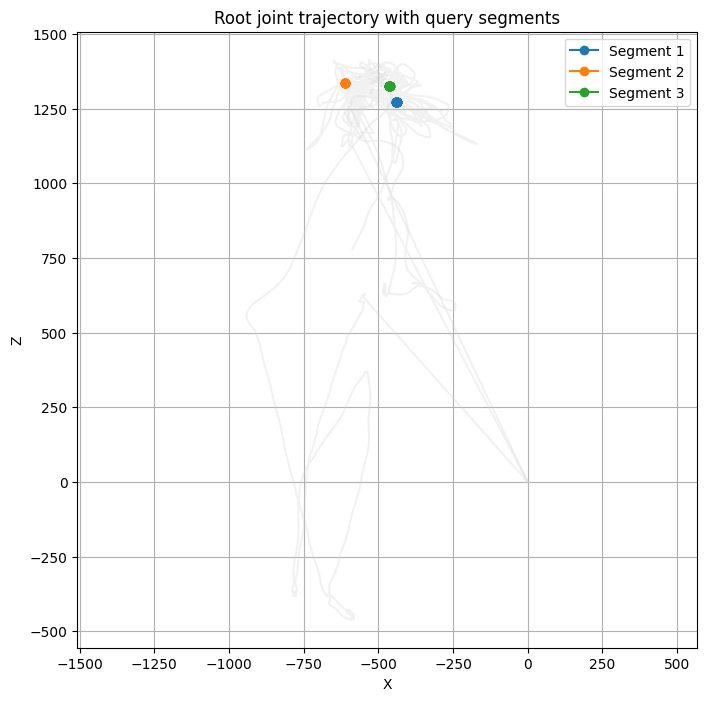

In [22]:
import matplotlib.pyplot as plt

def plot_query_segments_2d(bvh_files, results, segment_length=20):
    plt.figure(figsize=(8,8))
    for i, res in enumerate(results):
        file_id = res['file_id']
        start = res['start_frame']
        positions = load_root_positions_from_bvh(bvh_files[file_id])
        x_full, z_full = positions[:,0], positions[:,2]
        plt.plot(x_full, z_full, '-', color='lightgray', alpha=0.3)  # trayectoria completa

        # segmento de la query
        end = min(start+segment_length, len(positions))
        x_seg, z_seg = positions[start:end,0], positions[start:end,2]
        plt.plot(x_seg, z_seg, '-o', markersize=6, label=f'Segment {i+1}')

    plt.xlabel('X')
    plt.ylabel('Z')
    plt.title('Root joint trajectory with query segments')
    plt.grid(True)
    plt.axis('equal')
    plt.legend()
    plt.show()

# Llamada
plot_query_segments_2d(bvh_files, results, segment_length=20)
